# Parametric vs Non Parametric Model


**Parametric and Non-parametric** machine learning regression models continue to evolve, with recent advancements focusing on their respective strengths. Parametric models (e.g., linear regression) offer **interpretability, efficiency, and robustness with smaller datasets**, while nonparametric models (e.g., decision trees, K-nearest neighbors, neural networks) excel in **flexibility, power, and handling complex relationships** without strong assumptions about data distribution, though they often require more data and computational resources. The choice between them depends on data characteristics, desired interpretability, and computational constraints.

The distinction between parametric and nonparametric models in machine learning revolves around whether the model makes strong, fixed assumptions about the underlying data distribution and the functional form of the relationship between inputs and outputs.

Here's why Linear Regression is considered parametric and Neural Networks (generally) nonparametric:

## Linear Regression: A Parametric Model

Linear Regression is a classic example of a parametric model because it makes **explicit and fixed assumptions** about the functional form of the relationship between the independent variables ($X$) and the dependent variable ($Y$).

The core assumption is that the relationship can be represented by a linear equation:

$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n + \epsilon$

Where:
* $Y$ is the dependent variable.
* $X_i$ are the independent variables.
* $\beta_0, \beta_1, \dots, \beta_n$ are the **parameters** (coefficients) of the model. These are the values that the model learns from the data.
* $\epsilon$ is the error term, typically assumed to be normally distributed with a mean of zero and constant variance.

**Key reasons why it's parametric:**

1.  **Fixed Number of Parameters:** The number of parameters ($\beta$ values) in a linear regression model is fixed **before** training, determined by the number of input features. This number does not change regardless of how much data you feed into the model.
2.  **Predefined Functional Form:** The model explicitly assumes a linear relationship. It tries to find the best linear line (or hyperplane) that fits the data. If the true relationship is non-linear, linear regression will struggle to capture it accurately.
3.  **Strong Assumptions about Data Distribution:** It often assumes that the errors are normally distributed and have constant variance (homoscedasticity). Violation of these assumptions can affect the reliability of the model's inferences.



## Neural Networks: Generally Nonparametric Models

While neural networks *do* have parameters (the weights and biases of their connections), they are generally considered nonparametric because they **do not assume a fixed, predefined functional form** for the relationship between inputs and outputs. Instead, they are highly flexible and can learn arbitrary complex, non-linear mappings.

**Key reasons why they are generally nonparametric:**

1.  **Flexible Functional Form:** Neural networks, especially deep ones, are universal function approximators. This means they can approximate virtually any continuous function, no matter how complex. They don't assume a linear, quadratic, or any other specific predefined shape for the relationship.
2.  **Number of "Effective" Parameters Can Grow:** While the number of neurons and connections in a specific neural network architecture is fixed *once designed*, the *effective complexity* and the way it learns can adapt to the complexity of the data. For instance, in some cases (e.g., in the limit of infinitely wide networks, or with certain regularization techniques), they can behave like nonparametric models such as Gaussian processes. Also, more complex data might lead to the network learning more intricate features, effectively increasing its "parameter space" for fitting.
3.  **No Strong Assumptions on Data Distribution:** Unlike linear regression, neural networks don't make strong assumptions about the underlying distribution of the data or the error terms. They are designed to learn patterns directly from the data, even if those patterns are highly non-linear and the data distribution is complex.
4.  **Model Complexity Adapts to Data:** With more data, a neural network can learn a more nuanced and complex representation of the underlying function, effectively adapting its complexity to the data rather than being constrained by a fixed set of parameters from the outset.



**Important Note:** The terms "parametric" and "nonparametric" are not always black and white in machine learning. Some arguments can be made for neural networks having a parametric aspect given their fixed architecture. However, the prevailing view is that their immense flexibility and ability to approximate arbitrary functions without a prior fixed functional form place them firmly in the nonparametric category. They learn the "shape" of the function from the data itself, rather than trying to fit data into a pre-determined shape.

## Simple Visualization: Parametric vs Non-Parametric Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Create a synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y_linear = 2 * X + 1
y_nonlinear = np.sin(X) * 5
y = y_linear[:, 0] + y_nonlinear[:, 0] + np.random.normal(0, 2, X.shape[0]) # Add some noise

# 2. Implement and train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

# 3. Implement and train a basic Neural Network
# Define the model
nn_model = Sequential([
    Dense(10, input_shape=(1,), activation='relu'),
    Dense(1)
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse')

# Train the model
nn_model.fit(X, y, epochs=200, verbose=0) # Train for more epochs for better fitting

# 5. Store predictions from both models
y_pred_nn = nn_model.predict(X)

# Reshape predictions for consistent handling
y_pred_nn = y_pred_nn.flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


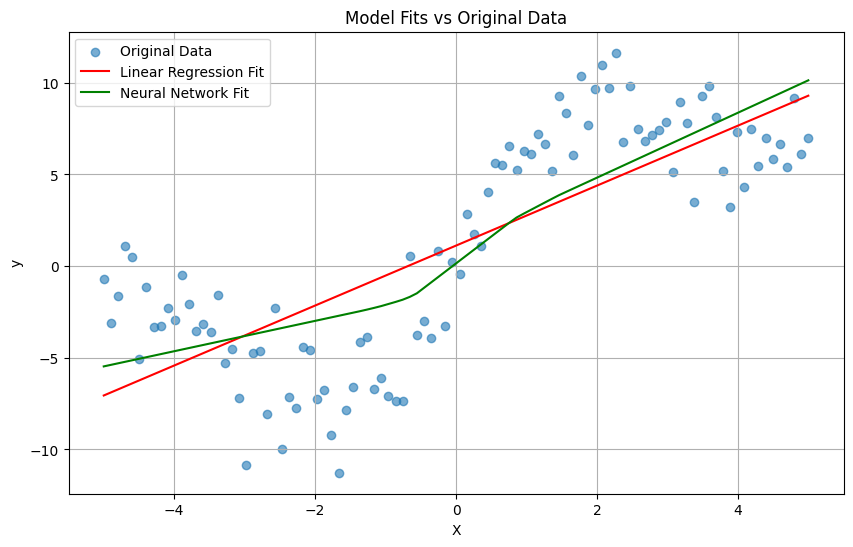

In [2]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data', alpha=0.6)
plt.plot(X, y_pred_linear, color='red', label='Linear Regression Fit')
plt.plot(X, y_pred_nn, color='green', label='Neural Network Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Model Fits vs Original Data')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation for Regression

Evaluating regression models is crucial to understand how well they perform in predicting the target variable. Unlike classification, where we assess categories, regression models predict continuous numerical values. Therefore, different metrics are needed to quantify the difference between the predicted values and the actual values. Choosing appropriate metrics helps in comparing different models, tuning hyperparameters, and ensuring the model is suitable for the specific problem.

Here are some common evaluation metrics for regression:

### Mean Absolute Error (MAE)

MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average of the absolute differences between the predicted and actual values.

Formula: $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

Interpretation: MAE is a linear score, meaning all individual differences are weighted equally in the average. A lower MAE indicates a better model fit. It is less sensitive to outliers compared to MSE.

### Mean Squared Error (MSE)

MSE measures the average of the squares of the errors. It is the most common regression metric.

Formula: $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

Interpretation: MSE penalizes larger errors more heavily than smaller ones due to the squaring. A lower MSE indicates a better model fit. Its unit is the square of the unit of the target variable, which can make it harder to interpret in the original scale.

### Root Mean Squared Error (RMSE)

RMSE is the square root of the MSE. It is widely used because it is in the same units as the target variable.

Formula: $RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

Interpretation: Like MSE, RMSE penalizes large errors. A lower RMSE indicates a better model fit. Being in the same units as the target variable makes it more interpretable than MSE.

### R-squared ($R^2$)

R-squared, also known as the coefficient of determination, measures the proportion of the variance in the dependent variable that is predictable from the independent variables.

Formula: $R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

Interpretation: R-squared values range from 0 to 1 (or can be negative if the model is worse than a horizontal line). An R-squared of 1 indicates that the model explains all the variability of the target variable. A higher R-squared indicates a better model fit. It provides a measure of how well the model's predictions approximate the real data points.

Using multiple evaluation metrics provides a more comprehensive understanding of a model's performance. For example, a model might have a low MAE, indicating small average errors, but a high MSE/RMSE, suggesting the presence of a few large errors (outliers) that are heavily penalized by squaring. R-squared gives a relative measure of fit compared to a simple mean model. Considering these metrics together helps in making a more informed decision about the model's effectiveness and its suitability for the specific problem and data characteristics.

## The Role of Hyperparameters

In machine learning, models have two main types of configurable aspects: **parameters** and **hyperparameters**. **Model parameters** are internal to the model and are learned from the data during training (e.g., the coefficients in linear regression or the weights and biases in a neural network). **Hyperparameters**, on the other hand, are external configurations that are set *before* the training process begins. They control the learning process itself or the structure of the model.

For nonparametric models like neural networks, hyperparameters play a particularly crucial role. Unlike parametric models where the functional form is fixed, nonparametric models have a flexible structure that can adapt to complex data. Hyperparameters are the knobs and levers that control this flexibility and complexity. By adjusting hyperparameters, we can influence the model's capacity to learn intricate patterns, its speed of learning, and its ability to generalize to unseen data.

### Hyperparameters in Neural Networks

Neural networks have several key hyperparameters that significantly impact their performance and structure:

*   **Number of Layers:** Refers to the depth of the network (excluding the input layer). More layers can help the network learn more complex hierarchical representations of the data, but also increase the risk of overfitting and computational cost.
*   **Number of Neurons per Layer:** Determines the width of each layer. A larger number of neurons can increase the model's capacity but may also lead to overfitting and increased training time.
*   **Activation Functions:** Non-linear functions applied to the output of each neuron (e.g., ReLU, sigmoid, tanh). They introduce non-linearity into the network, allowing it to learn complex, non-linear relationships in the data. The choice of activation function can impact training dynamics and performance.
*   **Learning Rate:** A crucial hyperparameter for the optimizer (e.g., Adam, SGD). It determines the step size at which the model's parameters are updated during training based on the calculated gradients. A high learning rate can lead to unstable training, while a low learning rate can make training very slow or get stuck in local minima.
*   **Number of Epochs:** The number of times the entire training dataset is passed forward and backward through the neural network. More epochs allow the model to learn more, but too many can lead to overfitting, especially with a high-capacity model.

Tuning these hyperparameters is essential for finding the optimal balance between model complexity and generalization ability. An inappropriately configured network might either be too simple to capture the underlying patterns (underfitting) or too complex, memorizing the training data instead of learning generalizable features (overfitting).

### Hyperparameter Tuning

The process of finding the best set of hyperparameters for a model is called **hyperparameter tuning** or **hyperparameter optimization**. Because the relationship between hyperparameters and model performance is often complex and non-linear, tuning is typically done through empirical experimentation.

Common techniques for hyperparameter tuning include:

*   **Grid Search:** Defines a grid of hyperparameter values to explore and trains the model for every possible combination of values in the grid. It is exhaustive but can be computationally expensive for many hyperparameters or large search spaces.
*   **Random Search:** Samples hyperparameter values randomly from defined distributions for a fixed number of iterations. Often more efficient than grid search, especially when only a few hyperparameters significantly impact performance.

Hyperparameter tuning is a critical step in developing high-performing nonparametric models, enabling practitioners to leverage the flexibility of these models effectively while mitigating risks like overfitting.

## Real-World Applications

The choice between parametric models like Linear Regression and nonparametric models like Neural Networks often depends on the nature of the data, the complexity of the underlying relationships, and the specific goals of the application (e.g., interpretability vs. prediction accuracy).

### Linear Regression Applications

Linear Regression is a simple yet powerful parametric model, often used when the relationship between variables is believed to be approximately linear, and interpretability is important.

*   **Economics:** Forecasting economic indicators such as GDP growth, inflation rates, or unemployment based on other economic factors. The coefficients provide insights into the impact of each factor.
*   **Finance:** Predicting stock prices or assessing the risk of financial assets based on historical data and market variables. Simple linear models can offer a baseline or be part of more complex strategies.
*   **Marketing:** Analyzing the relationship between advertising spending and sales revenue. This helps in understanding the effectiveness of different marketing channels.
*   **Healthcare:** Studying the relationship between dosage of a drug and patient outcomes, or identifying risk factors for diseases based on patient data.
*   **Simple Trend Analysis:** Identifying and projecting linear trends in data over time, such as sales growth or population changes.

Linear Regression is suitable in these cases because it is computationally efficient, easy to interpret (the coefficients directly show the direction and magnitude of the relationship), and can perform well with relatively small datasets if the linearity assumption holds.

### Neural Network Applications

Neural Networks, as highly flexible nonparametric models, excel in tasks involving complex, non-linear patterns where traditional parametric models would struggle. They are often used when high predictive accuracy is paramount and interpretability is less of a primary concern.

*   **Image Recognition:** Identifying objects, people, or scenes in images. Convolutional Neural Networks (CNNs) are the state-of-the-art for tasks like facial recognition, medical image analysis, and autonomous driving. Their nonparametric nature allows them to learn intricate visual features.
*   **Natural Language Processing (NLP):** Understanding, generating, and translating human language. Recurrent Neural Networks (RNNs) and Transformer networks (like those powering models such as GPT) are used for tasks like sentiment analysis, machine translation, and text generation. Their flexibility is key to handling the nuances and context in language.
*   **Speech Recognition:** Converting spoken language into text. Neural networks are used to process audio signals and identify phonetic patterns.
*   **Fraud Detection:** Identifying fraudulent transactions in financial data or detecting anomalies in network traffic. Neural networks can learn complex patterns that are indicative of fraudulent activity.
*   **Medical Diagnosis:** Assisting in diagnosing diseases from medical images (like X-rays or MRIs) or patient data, where complex interactions between numerous factors may be present.
*   **Recommender Systems:** Predicting user preferences and recommending products, movies, or music. Neural networks can model complex user-item interactions.

Neural Networks are preferred in these domains due to their ability to learn highly complex, non-linear relationships directly from raw data without requiring explicit feature engineering based on predefined assumptions. Their nonparametric flexibility allows them to capture intricate patterns that are beyond the scope of linear models, albeit often requiring large amounts of data and computational resources for training.

## Conclusion

This notebook explored the fundamental distinction between **parametric** and **nonparametric** machine learning models, using Linear Regression and Neural Networks as key examples.

* **Linear Regression**, a parametric model, assumes a fixed, predefined functional form (linear) and a fixed number of parameters. Its strengths lie in its **interpretability**, **efficiency**, and **robustness with smaller datasets** when the underlying relationship is indeed linear or close to it. However, its fixed structure makes it less flexible and potentially inaccurate when dealing with complex, non-linear relationships.

* **Neural Networks**, generally considered nonparametric models, do not assume a fixed functional form. Instead, they offer immense **flexibility** and **power** to learn arbitrary complex, non-linear mappings directly from data. They excel in tasks involving intricate patterns and large datasets, often achieving higher predictive accuracy than linear models in such scenarios. Their flexibility is controlled by **hyperparameters**, which need careful tuning. However, they are typically less interpretable ("black box" models), require more data to train effectively, and can be computationally expensive.

Model evaluation metrics such as MAE, MSE, RMSE, and R-squared are essential for quantifying the performance of regression models, providing objective ways to compare how well different models fit the data.

In summary, the choice between parametric and nonparametric models is not one-size-fits-all. It depends crucially on the **characteristics of the data**, the **complexity of the relationships** you are trying to model, and the **specific goals of your application**, including the trade-off between interpretability and predictive accuracy. Understanding the core assumptions and flexibilities of each type of model is vital for selecting the most appropriate tool for a given machine learning task.
